In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df=pd.read_csv("customer_churn_prediction_dataset.csv")

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.index

RangeIndex(start=0, stop=300, step=1)

In [6]:
df.isnull()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.isnull().values.any()

np.False_

In [9]:
df.drop(['customerID'],axis=1,inplace=True)

In [10]:
X=df.drop(['Churn'],axis=1)

In [11]:
y=df['Churn']

In [12]:
df['TotalCharges'].value_counts() #If blanks exist, clean them:

,count
TotalCharges,
2154.80,2
1051.68,1
3478.28,1
3983.25,1
1244.03,1
...,...
171.85,1
3502.84,1
2807.55,1


In [13]:
df['TotalCharges']=df['TotalCharges'].replace(" ",None)

In [14]:
df['TotalCharges'].dtype

dtype('float64')

# convert target value into numeric value

In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [16]:
print(y)

[1 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 1 0 1 1 0 1 1 1 0 1 1 0 1
 1 1 1 1 0 0 1 1 1 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 1 0
 1 1 0 1 1 0 0 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 1 1 0 0 0 0 0 1 1 1
 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 1
 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0
 0 1 1 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1
 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 0
 1 1 0 1]


In [17]:
print(le.classes_)

['No' 'Yes']


In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,5,No,Yes,No,No,Yes,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,Female,0,No,No,42,Yes,No phone service,DSL,Yes,Yes,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,Male,0,No,No,61,Yes,No phone service,No,No,Yes,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,Male,1,No,Yes,22,Yes,No,No,No internet service,No internet service,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,Male,1,Yes,Yes,21,No,No,DSL,No,No,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


now convert independent variable into numeric data set

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            300 non-null    object 
 1   SeniorCitizen     300 non-null    int64  
 2   Partner           300 non-null    object 
 3   Dependents        300 non-null    object 
 4   tenure            300 non-null    int64  
 5   PhoneService      300 non-null    object 
 6   MultipleLines     300 non-null    object 
 7   InternetService   300 non-null    object 
 8   OnlineSecurity    300 non-null    object 
 9   OnlineBackup      300 non-null    object 
 10  DeviceProtection  300 non-null    object 
 11  TechSupport       300 non-null    object 
 12  StreamingTV       300 non-null    object 
 13  StreamingMovies   300 non-null    object 
 14  Contract          300 non-null    object 
 15  PaperlessBilling  300 non-null    object 
 16  PaymentMethod     300 non-null    object 
 1

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod'])],remainder='passthrough')
X=ct.fit_transform(X)

In [21]:
print(X[:18])

[[0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00
  1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  5.00000e+00 2.74300e+01 1.37150e+02]
 [1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 1.00000e+00

# Now check weather dataset or balance or imbalance

In [22]:
df['Churn'].value_counts()

,count
Churn,
No,161
Yes,139


In [23]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,53.666667
Yes,46.333333


<Axes: xlabel='Churn', ylabel='count'>

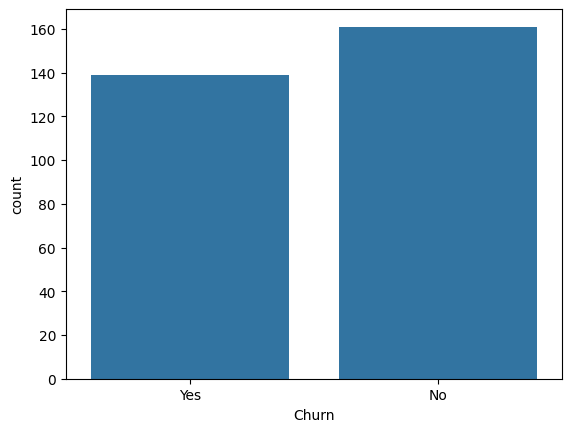

In [24]:
import seaborn as sns
sns.countplot(x='Churn',data=df)

# Balance imbalance dataset

In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

#split first

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Apply SMOTE only on training data

In [27]:
smote=SMOTE(random_state=42)
X_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)

# Check new balance

In [28]:
print(pd.Series(y_train_sm).value_counts())

0    127
1    127
Name: count, dtype: int64


#Feature Scaling

In [43]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_sm=sc.fit_transform(X_train_sm)
X_test=sc.transform(X_test)

In [40]:
print(X_train_sm)

[[1.00000000e+00 0.00000000e+00 0.00000000e+00 ... 6.00000000e+01
  9.02500000e+01 5.41500000e+03]
 [0.00000000e+00 1.00000000e+00 1.00000000e+00 ... 6.00000000e+00
  3.42800000e+01 2.05680000e+02]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 1.00000000e+00
  3.98000000e+01 3.98000000e+01]
 ...
 [4.75225340e-01 5.24774660e-01 4.75225340e-01 ... 6.00000000e+00
  1.00702836e+02 6.04217019e+02]
 [6.00139028e-01 3.99860972e-01 1.00000000e+00 ... 1.62002781e+01
  2.50878582e+01 4.05940735e+02]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00 ... 7.65331928e+00
  5.56279046e+01 4.02219989e+02]]


In [41]:
print(X_test)

[[-2.83687236  0.81845618 -2.9163298  ... -1.59130398 -2.32851631
  -1.22636472]
 [ 1.2068458  -3.22526198 -2.9163298  ... -1.62929061 -2.30215215
  -1.22646449]
 [-2.83687236  0.81845618  1.11106873 ... -1.62482159 -2.37941377
  -1.22703129]
 ...
 [ 1.2068458  -3.22526198 -2.9163298  ... -1.68962232 -2.28510089
  -1.2270607 ]
 [-2.83687236  0.81845618 -2.9163298  ... -1.64716667 -2.34488405
  -1.22689727]
 [ 1.2068458  -3.22526198  1.11106873 ... -1.60247652 -2.32391479
  -1.22640589]]


#Training the logistic regression model on training set

In [50]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(max_iter=1000,random_state=0)
classifier.fit(X_train_sm,y_train_sm)

LogisticRegression(max_iter=1000, random_state=0)

#predicting the test set result

In [51]:
y_pred=classifier.predict(X_test)

In [53]:
print(np.column_stack((y_pred, y_test)))

[[0 0]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [0 1]
 [0 1]
 [1 1]
 [1 0]
 [0 0]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [1 1]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 1]
 [1 0]
 [1 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 1]
 [1 1]
 [1 0]
 [1 0]
 [1 1]
 [1 0]
 [1 0]
 [1 0]
 [0 0]
 [1 0]
 [0 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 0]
 [1 0]]


#making the confusion matrix

In [54]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)


In [55]:
print(cm)

[[ 6 28]
 [ 7 19]]


In [56]:
accuracy_score(y_test,y_pred)

0.4166666666666667

In [57]:
print(X_train_sm.shape)
print(X_test.shape)

(254, 45)
(60, 45)


#we have 45 data reduce it in 2D

In [62]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_train_pca=pca.fit_transform(X_train_sm)
X_test=pca.transform(X_test)

In [63]:
print(X_train_sm.shape)
print(X_test.shape)

(254, 2)
(60, 2)


#Train model on PCA data for visualisation only

In [64]:
classifier_pca=LogisticRegression(random_state=0)
classifier_pca.fit(X_train_pca,y_train_sm)

LogisticRegression(random_state=0)

#visuallizing the training set result

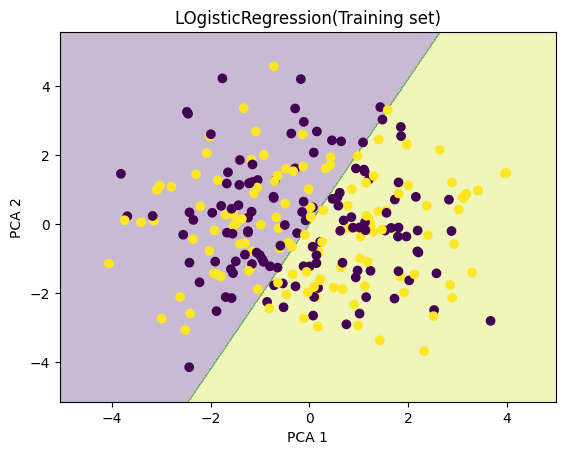

In [75]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
X_set,y_set=X_train_pca,y_train_sm
X1,X2=np.meshgrid(
    np.arange(X_set[:,0].min()-1,X_set[:,0].max()+1,0.01),
    np.arange(X_set[:,1].min()-1,X_set[:,1].max()+1,0.01)
)
plt.contourf(
    X1,X2,classifier_pca.predict(np.array([X1.ravel(),X2.ravel()]).T).reshape(X1.shape),alpha=0.3
    )
plt.scatter(X_set[:,0],X_set[:,1],c=y_set)
plt.title('LOgisticRegression(Training set)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()


#Visualising the Test set results

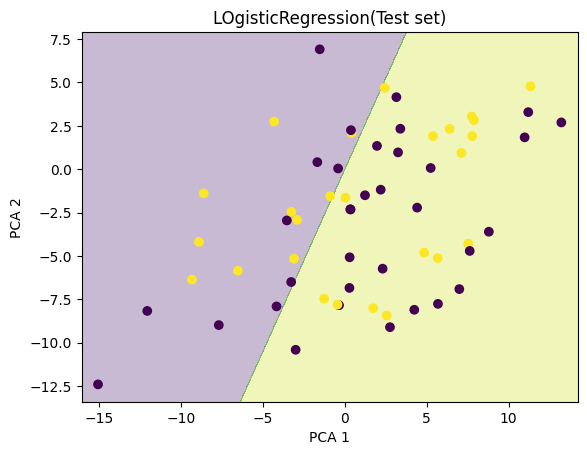

In [79]:
X_set,y_set=X_test,y_test
X1,X2=np.meshgrid(
    np.arange(X_set[:,0].min()-1,X_set[:,0].max()+1,0.01),
    np.arange(X_set[:,1].min()-1,X_set[:,1].max()+1,0.01)
)
plt.contourf(X1,X2,classifier_pca.predict(np.array([X1.ravel(),X2.ravel()]).T).reshape(X1.shape),alpha=0.3
             )
plt.scatter(X_set[:,0],X_set[:,1],c=y_set)
plt.title('LOgisticRegression(Test set)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()